# prep-sbi-extra — SBI pile for two additional face datasets

Builds a **self-blended (SBI) pile** plus its paired **real** source crops from two
Kaggle face datasets, using the same construction as `prep-m4.ipynb` so the images are
drop-in compatible with the existing analysis.

## Inputs to attach

1. `wheels-m4` (notebook) — RetinaFace wheel and torch-hub weights
2. `ruwadnaswan/dataset-formsib` — halfFace, South Asian, mask-wearing subjects
3. `ruwadnaswan/fixed-naming-msib-dataset-2` — Asian / Non-Asian faces

## What it does

- keeps **full faces only** — Dataset 1 mixes portrait full faces with landscape
  eye-strips, so those are filtered out by aspect ratio and then by a RetinaFace
  landmark check (an eye-strip has no nose or mouth, so it fails)
- re-detects and re-crops **every** image at a 1.3x margin, clamping the window to the
  image rather than padding it, so no output pixel is synthetic
- generates **one SBI image per real crop**, pixel-aligned with it
- writes a manifest and a README describing the layout

## Output layout

```text
sbi_faces_extra/
├── README.md
├── manifest.csv
└── images/
    ├── halfface_south_asian/   real/  sbi/
    ├── msib_asian/             real/  sbi/
    └── msib_non_asian/         real/  sbi/
```

`real/x.jpg` and `sbi/x.jpg` share a filename — same face, one with a blend seam.

> Only the `sbi` pile is built here. The `xform` texture control from `prep-m4` is not
> included; without it these images can show *that* a feature responds to blending, but
> not that it responds to the boundary rather than the blur/colour change.

## 1. Offline install and paths

In [1]:
import subprocess, shutil, os, sys, time, json
from pathlib import Path
import torch

W = Path("/kaggle/input/notebooks/raihanzahin/wheels-m4/wheels_m4")
r = subprocess.run(["pip", "install", "--no-index", "--find-links", str(W),
                    "retinaface-pytorch"], capture_output=True, text=True)
print("pip RC =", r.returncode)
if r.returncode:
    print(r.stdout[-1200:], r.stderr[-1200:])

HUB = Path("/kaggle/working/torch_hub")
if not HUB.exists():
    shutil.copytree(W / "torch_hub", HUB)
torch.hub.set_dir(str(HUB))
print("hub:", sorted(p.name for p in (HUB / "checkpoints").iterdir()))

# ---- dataset roots ----
D1_ROOT = Path("/kaggle/input/datasets/ruwadnaswan/dataset-formsib")
D2_ROOT = Path("/kaggle/input/datasets/ruwadnaswan/fixed-naming-msib-dataset-2/"
               "Facial Asian and Non Asian Datasets")

# dataset 1 is wrapped in three identically named folders; descend automatically
d1 = D1_ROOT
for _ in range(5):
    subs = [p for p in d1.iterdir() if p.is_dir()]
    if len(subs) == 1:
        d1 = subs[0]
    else:
        break
D1_FULL = d1 / "Dataset1_Full Facial Image"

for p in [D1_FULL, D2_ROOT / "Asian Data" / "Filtered Crop Images",
          D2_ROOT / "Non-Asian Data" / "Filtered Crop Images"]:
    print(f"{'OK  ' if p.exists() else 'MISS'}  {p}")

OUT      = Path("/kaggle/working/sbi_faces_extra")
IMG_ROOT = OUT / "images"
IMG_ROOT.mkdir(parents=True, exist_ok=True)

def free_gb():
    return shutil.disk_usage("/kaggle/working").free / 1024**3
print(f"\nfree: {free_gb():.1f} GB")

pip RC = 0
hub: ['retinaface_resnet50_2020-07-20-f168fae3c.zip', 'retinaface_resnet50_2020-07-20.pth']
OK    /kaggle/input/datasets/ruwadnaswan/dataset-formsib/halfFace A face covering mask dataset of South Asian people/halfFace_A face covering mask dataset of South Asian people/halfFace_A face covering mask dataset of South Asian people/Dataset1_Full Facial Image
OK    /kaggle/input/datasets/ruwadnaswan/fixed-naming-msib-dataset-2/Facial Asian and Non Asian Datasets/Asian Data/Filtered Crop Images
OK    /kaggle/input/datasets/ruwadnaswan/fixed-naming-msib-dataset-2/Facial Asian and Non Asian Datasets/Non-Asian Data/Filtered Crop Images

free: 19.3 GB


## 2. Build the candidate inventory

Two cheap filters before any GPU work:

- **short side >= 128 px** — anything smaller cannot survive a 256x256 crop, and the
  64x64 folders in Dataset 2 are deliberately excluded for the same reason
- **portrait only for Dataset 1** — the eye-strips are landscape, so aspect ratio
  removes most of them for free

In [2]:
import pandas as pd
from PIL import Image

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MIN_SIDE = 128

rows = []

# ---- dataset 1: one folder per identity (p001 ... p166) ----
for person_dir in sorted(p for p in D1_FULL.iterdir() if p.is_dir()):
    for f in sorted(person_dir.iterdir()):
        if f.suffix.lower() not in IMG_EXT:
            continue
        rows.append({"source_path": str(f), "group": "halfface_south_asian",
                     "dataset": "halfFace", "demographic": "south_asian",
                     "identity": person_dir.name, "stem": f.stem})

# ---- dataset 2: loose crops only (skip the 64x64 subfolders) ----
for folder, demo in [("Asian Data", "asian"), ("Non-Asian Data", "non_asian")]:
    d = D2_ROOT / folder / "Filtered Crop Images"
    for f in sorted(d.iterdir()):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            rows.append({"source_path": str(f), "group": f"msib_{demo}",
                         "dataset": "msib", "demographic": demo,
                         "identity": None, "stem": f.stem})

inv = pd.DataFrame(rows)
print(f"raw files: {len(inv):,}")

# read sizes once
sizes = []
for p in inv.source_path:
    try:
        with Image.open(p) as im:
            sizes.append(im.size)
    except Exception:
        sizes.append((0, 0))
inv["src_w"] = [s[0] for s in sizes]
inv["src_h"] = [s[1] for s in sizes]
inv["short_side"] = inv[["src_w", "src_h"]].min(axis=1)
inv["portrait"] = inv.src_h >= inv.src_w * 0.95

before = len(inv)
inv["keep_size"]   = inv.short_side >= MIN_SIDE
# aspect filter applies only to dataset 1, where the eye-strips live
inv["keep_aspect"] = (inv.dataset != "halfFace") | inv.portrait
inv = inv[inv.keep_size & inv.keep_aspect].drop(
    columns=["keep_size", "keep_aspect", "portrait"]).reset_index(drop=True)

print(f"after size >= {MIN_SIDE}px and portrait filter: {len(inv):,}  "
      f"(dropped {before - len(inv):,})")
print()
print(inv.groupby(["group"]).agg(
    images=("source_path", "size"),
    identities=("identity", lambda s: s.nunique() if s.notna().any() else 0),
    med_short=("short_side", "median")).to_string())

raw files: 4,051
after size >= 128px and portrait filter: 3,272  (dropped 779)

                      images  identities  med_short
group                                              
halfface_south_asian     931         164      351.0
msib_asian              1017           0      211.0
msib_non_asian          1324           0      211.0


## 3. Detector, full-face test, and crop helpers

`is_full_face` is the real filter. An eye-strip can still produce a bounding box, but it
cannot produce five landmarks with a nose and both mouth corners below the eyes — so the
landmark geometry is what separates a face from a crop of a face.

`crop_face` takes the face box expanded by a 1.3x margin, but **clamps the window to the
image instead of padding**: the side is capped at the shorter image dimension and the
window shifts inward at the edges. No synthetic pixels are ever introduced. Both source
datasets are already tight portrait crops, so the requested margin often cannot be met —
`plan_crop` returns the margin actually achieved and it is recorded per image.

In [3]:
import numpy as np, cv2
from retinaface.pre_trained_models import get_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
detector = get_model("resnet50_2020-07-20", max_size=1024, device=DEVICE)
detector.eval()
print("detector on", DEVICE)

CROP_SIZE, MARGIN, MIN_SCORE = 256, 1.30, 0.90


def detect_best(rgb):
    """Highest-scoring face. RetinaFace returns a sentinel row (score -1) when it
    finds nothing, so length alone is not a success check."""
    out = detector.predict_jsons(rgb)
    best, best_s, best_lm = None, -1.0, None
    for d in out:
        if not d.get("bbox") or d.get("score", -1) < 0:
            continue
        if d["score"] > best_s:
            best, best_s, best_lm = d["bbox"], d["score"], d.get("landmarks")
    return (best, best_s, best_lm) if best is not None else (None, None, None)


def is_full_face(bbox, lm, shape, min_score_lm=5):
    """Reject eye-strips: require 5 landmarks, all inside the image, with the nose
    below both eyes and the mouth corners below the nose."""
    if bbox is None or lm is None or len(lm) < min_score_lm:
        return False, "no_landmarks"
    h, w = shape[:2]
    pts = np.asarray(lm, dtype=float)
    if (pts[:, 0] < 0).any() or (pts[:, 0] > w).any() or \
       (pts[:, 1] < 0).any() or (pts[:, 1] > h).any():
        return False, "landmark_outside"
    eye_l, eye_r, nose, mou_l, mou_r = pts[0], pts[1], pts[2], pts[3], pts[4]
    if nose[1] <= max(eye_l[1], eye_r[1]):
        return False, "nose_above_eyes"
    if min(mou_l[1], mou_r[1]) <= nose[1]:
        return False, "mouth_above_nose"
    bw, bh = bbox[2] - bbox[0], bbox[3] - bbox[1]
    if min(bw, bh) < 64:
        return False, "face_too_small"
    return True, "ok"


def plan_crop(bbox, shape, margin=MARGIN):
    """Work out the crop window without touching pixels.

    The window is the face box expanded by `margin`, but it never leaves the image:
    the side is capped at the shorter image dimension, and the window is then shifted
    inward if it would overhang an edge. So no synthetic pixels are ever introduced.

    The price is that `margin` cannot always be honoured. Returns the window plus the
    margin actually achieved, which is recorded per image as `margin_used`.
    """
    h, w = shape[:2]
    x1, y1, x2, y2 = bbox
    bw, bh = x2 - x1, y2 - y1
    face = max(bw, bh)

    # cap the square so it fits inside the image at all
    side = min(face * margin, w, h)

    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    x1n, y1n = cx - side / 2, cy - side / 2

    # shift inward rather than pad
    x1n = min(max(x1n, 0.0), w - side)
    y1n = min(max(y1n, 0.0), h - side)

    return (int(round(x1n)), int(round(y1n)), int(round(side)),
            side / max(face, 1e-9))


def crop_face(rgb, bbox, size=CROP_SIZE, margin=MARGIN):
    """Square crop around the face, clamped to the image. Never pads."""
    x, y, side, _ = plan_crop(bbox, rgb.shape, margin)
    patch = rgb[y:y + side, x:x + side]
    if patch.size == 0:
        return None
    return cv2.resize(patch, (size, size), interpolation=cv2.INTER_AREA)


def load_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:                      # cv2 fails on some gifs/cmyk jpegs
        try:
            return np.asarray(Image.open(path).convert("RGB"))
        except Exception:
            return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/hub.py:883: FutureWarning: Falling back to the old format < 1.6. This support will be deprecated in favor of default zipfile format introduced in 1.6. Please redo torch.save() to save it in the new zipfile format.
  return _legacy_zi

detector on cuda


## 4. SBI generator

Identical to `prep-m4`: a deformed elliptical mask with a soft alpha ramp, and a source
copy perturbed in brightness, contrast, colour, resolution and sharpness before being
blended back. The seed is stored so the exact mask can be regenerated later.

In [4]:
def _rand_mask(size, rng):
    h = w = size
    m = np.zeros((h, w), np.float32)
    cx = w / 2 + rng.uniform(-0.02, 0.02) * w
    cy = h / 2 + rng.uniform(-0.04, 0.04) * h
    ax = w * rng.uniform(0.28, 0.38)
    ay = h * rng.uniform(0.34, 0.44)
    cv2.ellipse(m, (int(cx), int(cy)), (int(ax), int(ay)),
                rng.uniform(-12, 12), 0, 360, 1.0, -1)

    g, amp = 8, rng.uniform(3, 8)
    dx = cv2.resize(rng.normal(0, 1, (g, g)).astype(np.float32), (w, h)) * amp
    dy = cv2.resize(rng.normal(0, 1, (g, g)).astype(np.float32), (w, h)) * amp
    xx, yy = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
    m = cv2.remap(m, xx + dx, yy + dy, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

    k = int(rng.integers(3, 13)) * 2 + 1
    return np.clip(cv2.GaussianBlur(m, (k, k), rng.uniform(3, 12)), 0, 1)[..., None]


def _source_transform(img, rng):
    x = img.astype(np.float32)
    x *= rng.uniform(0.92, 1.08)                                # brightness
    x = (x - x.mean()) * rng.uniform(0.92, 1.08) + x.mean()     # contrast
    x += rng.normal(0, 1, 3) * rng.uniform(0, 6)                # per-channel shift
    x = np.clip(x, 0, 255).astype(np.uint8)

    if rng.random() < 0.7:                                       # resolution mismatch
        s = rng.uniform(0.5, 0.95)
        small = cv2.resize(x, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
        x = cv2.resize(small, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)

    if rng.random() < 0.5:
        x = cv2.GaussianBlur(x, (5, 5), rng.uniform(0.4, 1.6))
    else:
        x = np.clip(cv2.addWeighted(x, 1.5, cv2.GaussianBlur(x, (5, 5), 1.0), -0.5, 0),
                    0, 255).astype(np.uint8)

    M = np.float32([[rng.uniform(0.985, 1.015), 0, rng.uniform(-3, 3)],
                    [0, rng.uniform(0.985, 1.015), rng.uniform(-3, 3)]])
    return cv2.warpAffine(x, M, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REFLECT)


def make_sbi(rgb, seed):
    """Self-blended image: same content and framing, plus a blend seam."""
    rng = np.random.default_rng(seed)
    src = _source_transform(rgb, rng)
    a = _rand_mask(rgb.shape[0], rng)
    out = src.astype(np.float32) * a + rgb.astype(np.float32) * (1 - a)
    return np.clip(out, 0, 255).astype(np.uint8), a[..., 0]

## 5. Smoke test — check the full-face filter before the long run

Look for two things: that eye-strips are rejected with a sensible reason, and that the
accepted crops are tight and centred like the FF++ ones.

/tmp/ipykernel_64/2411943605.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(4, len(g)), random_state=0))


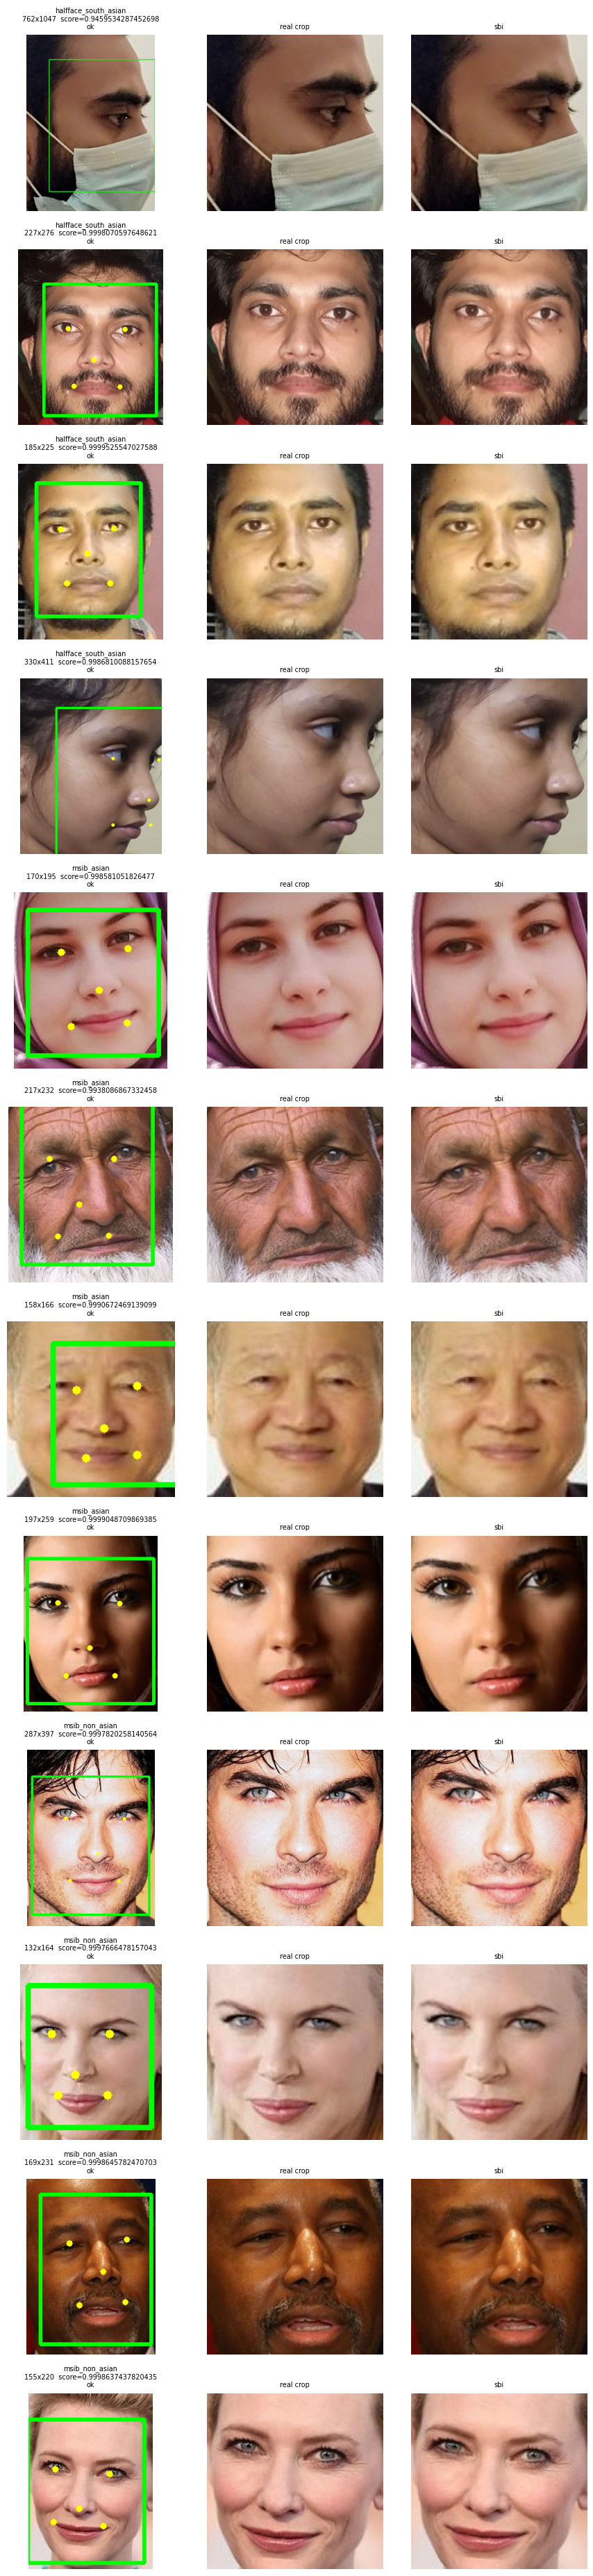

In [5]:
import matplotlib.pyplot as plt

probe = (inv.groupby("group", group_keys=False)
            .apply(lambda g: g.sample(min(4, len(g)), random_state=0))
            .reset_index(drop=True))

rows_shown = []
for r in probe.itertuples(index=False):
    rgb = load_rgb(r.source_path)
    if rgb is None:
        print("unreadable:", r.source_path); continue
    bbox, score, lm = detect_best(rgb)
    ok, why = is_full_face(bbox, lm, rgb.shape)
    crop = crop_face(rgb, bbox) if ok else None
    sbi = make_sbi(crop, seed=0)[0] if crop is not None else None
    rows_shown.append((r.group, rgb, bbox, lm, score, ok, why, crop, sbi))

n = len(rows_shown)
fig, axes = plt.subplots(n, 3, figsize=(9, 3.1 * n), squeeze=False)
for i, (grp, rgb, bbox, lm, score, ok, why, crop, sbi) in enumerate(rows_shown):
    vis = rgb.copy()
    if bbox:
        x1, y1, x2, y2 = [int(v) for v in bbox]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0) if ok else (255, 0, 0), 3)
    if lm:
        for (px, py) in np.asarray(lm, dtype=int):
            cv2.circle(vis, (px, py), 4, (255, 255, 0), -1)
    axes[i][0].imshow(vis)
    axes[i][0].set_title(f"{grp}\n{rgb.shape[1]}x{rgb.shape[0]}  "
                         f"score={score if score else '-'}\n{why}", fontsize=7)
    if crop is not None:
        axes[i][1].imshow(crop); axes[i][1].set_title("real crop", fontsize=7)
        axes[i][2].imshow(sbi);  axes[i][2].set_title("sbi", fontsize=7)
    else:
        axes[i][1].text(.5, .5, "REJECTED", ha="center"); 
        axes[i][2].text(.5, .5, "-", ha="center")
    for a in axes[i]:
        a.axis("off")
plt.tight_layout(); plt.show()

---

**Stop here and check the smoke test** before going further.

Remaining sections: a detection pass that records how much padding each crop would
need, a data-driven choice of padding threshold, then cropping, SBI generation,
splits, manifest, README and packaging.


## 6. Detection pass

Detect once over everything and record the results, including how much **padding** each
crop would need. Nothing is cropped or written yet — the padding threshold is chosen
from the distribution in the next section rather than guessed in advance.

Padding matters more than it sounds. `BORDER_REPLICATE` smears edge pixels into bands,
and those bands are sharp texture discontinuities — the same class of artifact the seam
analysis is trying to measure. Dataset 2's images are already tightly cropped, so
expanding to a 1.3x margin pushes well past their borders.

In [6]:
from tqdm.auto import tqdm
import pandas as pd, numpy as np, time

det_rows = []
t0 = time.time()

for i, r in enumerate(tqdm(inv.itertuples(index=False), total=len(inv), desc="detecting")):
    rgb = load_rgb(r.source_path)
    if rgb is None:
        det_rows.append({"idx": i, "ok": False, "reason": "unreadable"})
        continue

    bbox, score, lm = detect_best(rgb)
    if bbox is None or score < MIN_SCORE:
        det_rows.append({"idx": i, "ok": False, "reason": "no_face"})
        continue

    ok, why = is_full_face(bbox, lm, rgb.shape)
    det_rows.append({
        "idx": i, "ok": ok, "reason": why, "det_score": float(score),
        "bbox_x1": float(bbox[0]), "bbox_y1": float(bbox[1]),
        "bbox_x2": float(bbox[2]), "bbox_y2": float(bbox[3]),
        "margin_used": plan_crop(bbox, rgb.shape, MARGIN)[3],
    })

det  = pd.DataFrame(det_rows).set_index("idx")
cand = inv.reset_index(drop=True).join(det)
cand["ok"] = cand.ok.fillna(False)
cand.to_csv("/kaggle/working/detection_pass.csv", index=False)

print(f"\ndetection done in {(time.time()-t0)/60:.1f} min")
print()
print(cand.reason.value_counts().to_string())
print(f"\nfull faces: {int(cand.ok.sum()):,} / {len(cand):,}")
print()
print(cand[cand.ok].groupby("group").size().rename("full_faces").to_string())

detecting:   0%|          | 0/3272 [00:00<?, ?it/s]

libpng warning: sBIT: bad length
libpng warning: sBIT: bad length
libpng warning: sBIT: bad length
libpng warning: sBIT: bad length
libpng warning: sBIT: bad length



detection done in 0.6 min

reason
ok                  3158
landmark_outside      43
no_face               35
mouth_above_nose      27
nose_above_eyes        9

full faces: 3,158 / 3,272

group
halfface_south_asian     853
msib_asian               998
msib_non_asian          1307


## 7. How much margin was actually achieved

Both sources are already tight portrait face crops, so the requested 1.3x margin often
does not fit. Rather than padding the shortfall with invented pixels, the window is
clamped to the image and the **achieved** margin is recorded.

A value of 1.30 means the full margin was available. Below 1.00 means the square is
smaller than the face box, so the crop clips forehead or chin. Nothing is dropped for
this — the distribution is simply reported, because face-to-frame ratio varies between
images and that has to be documented rather than hidden.

achieved margin, by group  (1.30 = full margin available)

                        min    10%    50%    90%  max
group                                                
halfface_south_asian  0.798  0.925  1.025  1.196  1.3
msib_asian            0.702  0.881  1.000  1.158  1.3
msib_non_asian        0.639  0.853  0.958  1.119  1.3

how often the full margin was available:

margin_used           <0.8  0.8-0.9  0.9-1.0  1.0-1.15  1.15-1.29  1.30 (full)
group                                                                         
halfface_south_asian     1       32      308       365        121           26
msib_asian              11      142      354       377         94           20
msib_non_asian          45      269      534       372         72           15

crops that clip into the face box (margin < 1.0): 1,653 / 3,158 (52.3%)


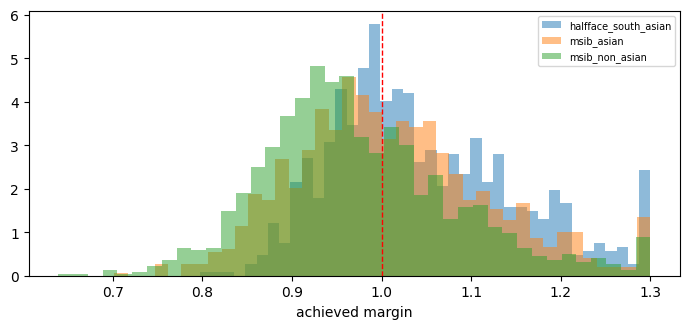

In [7]:
import matplotlib.pyplot as plt

good = cand[cand.ok].copy()

print("achieved margin, by group  (1.30 = full margin available)\n")
print(good.groupby("group")["margin_used"]
      .describe(percentiles=[0.1, 0.5, 0.9])[["min", "10%", "50%", "90%", "max"]]
      .round(3).to_string())

print("\nhow often the full margin was available:\n")
bins = pd.cut(good.margin_used, [0, 0.8, 0.9, 1.0, 1.15, 1.29, 1.31],
              labels=["<0.8", "0.8-0.9", "0.9-1.0", "1.0-1.15", "1.15-1.29", "1.30 (full)"])
print(pd.crosstab(good.group, bins).to_string())

clipped = good.margin_used < 1.0
print(f"\ncrops that clip into the face box (margin < 1.0): "
      f"{int(clipped.sum()):,} / {len(good):,} ({clipped.mean():.1%})")

fig, ax = plt.subplots(figsize=(7, 3.4))
for g, sub in good.groupby("group"):
    ax.hist(sub.margin_used, bins=40, alpha=.5, label=g, density=True)
ax.axvline(1.0, c="r", ls="--", lw=1)
ax.set_xlabel("achieved margin"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 8. Build the pile — crop and generate SBI

No detection here; it reuses the boxes stored in section 6, so this pass is only image
I/O. Every full face is kept — nothing is dropped for geometry, since clamping means no
crop ever needs invented pixels.

In [8]:
from tqdm.auto import tqdm
import pandas as pd, numpy as np, re, time

def safe_name(s):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(s)).strip("_")[:80]

for g in inv.group.unique():
    for pile in ["real", "sbi"]:
        (IMG_ROOT / g / pile).mkdir(parents=True, exist_ok=True)

# only the detection filters drop anything now
rejects = cand.loc[~cand.ok, ["source_path", "group", "reason"]].to_dict("records")
keep = cand[cand.ok].reset_index(drop=True)
print(f"building {len(keep):,} pairs  (rejected {len(rejects):,})")

records, seen_names = [], set()
t0 = time.time()

for i, r in enumerate(tqdm(keep.itertuples(index=False), total=len(keep), desc="building")):
    rgb = load_rgb(r.source_path)
    if rgb is None:
        rejects.append({"source_path": r.source_path, "group": r.group,
                        "reason": "unreadable_second_pass"})
        continue

    bbox = [r.bbox_x1, r.bbox_y1, r.bbox_x2, r.bbox_y2]
    crop = crop_face(rgb, bbox)
    if crop is None:
        rejects.append({"source_path": r.source_path, "group": r.group,
                        "reason": "empty_crop"})
        continue

    name = safe_name(r.stem)
    if (r.group, name) in seen_names:          # dataset 2 has duplicate stems
        name = f"{name}__{i}"
    seen_names.add((r.group, name))

    # seed derived from the output name so re-runs reproduce the same masks
    seed = int(pd.util.hash_pandas_object(pd.Series([f"{r.group}/{name}"])).iloc[0] % (2**31))
    sbi, _ = make_sbi(crop, seed=seed)

    for pile, arr in [("real", crop), ("sbi", sbi)]:
        cv2.imwrite(str(IMG_ROOT / r.group / pile / f"{name}.jpg"),
                    cv2.cvtColor(arr, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 95])

    records.append({
        "filename": f"{name}.jpg",
        "real_path": f"images/{r.group}/real/{name}.jpg",
        "sbi_path":  f"images/{r.group}/sbi/{name}.jpg",
        "group": r.group, "dataset": r.dataset, "demographic": r.demographic,
        "identity": r.identity, "sbi_seed": seed,
        "source_path": r.source_path, "src_w": r.src_w, "src_h": r.src_h,
        "det_score": r.det_score, "margin_used": round(float(r.margin_used), 4),
        "bbox_x1": r.bbox_x1, "bbox_y1": r.bbox_y1,
        "bbox_x2": r.bbox_x2, "bbox_y2": r.bbox_y2,
    })

man = pd.DataFrame(records)
rej = pd.DataFrame(rejects)

print(f"\nkept {len(man):,} pairs in {(time.time()-t0)/60:.1f} min   "
      f"rejected {len(rej):,}")
print()
print(rej.reason.value_counts().to_string())
print()
print(man.groupby("group").agg(pairs=("filename", "size"),
                               med_margin=("margin_used", "median")).to_string())

building 3,158 pairs  (rejected 114)


building:   0%|          | 0/3158 [00:00<?, ?it/s]

libpng warning: sBIT: bad length
libpng warning: sBIT: bad length
libpng warning: sBIT: bad length
libpng warning: sBIT: bad length
libpng warning: sBIT: bad length



kept 3,158 pairs in 0.3 min   rejected 114

reason
landmark_outside    43
no_face             35
mouth_above_nose    27
nose_above_eyes      9

                      pairs  med_margin
group                                  
halfface_south_asian    853      1.0249
msib_asian              998      1.0000
msib_non_asian         1307      0.9584


## 9. Splits

Dataset 1 has identity folders, so its split is **identity-disjoint** — no person
appears in more than one split. Dataset 2 has no identity information (filenames are
arbitrary), so it can only be split per file. That limitation is recorded in the
README, because a same-person leak there cannot be ruled out.

In [9]:
import numpy as np

SEED = 42
FRACS = {"train": 0.70, "val": 0.15, "test": 0.15}
rng = np.random.default_rng(SEED)

man["split"] = None

# identity-disjoint where identities exist
has_id = man.identity.notna()
ids = sorted(man.loc[has_id, "identity"].unique())
perm = rng.permutation(len(ids))
n_tr = int(round(FRACS["train"] * len(ids)))
n_va = int(round(FRACS["val"] * len(ids)))
id_split = {}
for rank, pos in enumerate(perm):
    id_split[ids[pos]] = ("train" if rank < n_tr else
                          "val" if rank < n_tr + n_va else "test")
man.loc[has_id, "split"] = man.loc[has_id, "identity"].map(id_split)

# per-file elsewhere, stratified by group
for g, idx in man.loc[~has_id].groupby("group").groups.items():
    idx = np.array(list(idx)); rng.shuffle(idx)
    a = int(round(FRACS["train"] * len(idx)))
    b = a + int(round(FRACS["val"] * len(idx)))
    man.loc[idx[:a], "split"] = "train"
    man.loc[idx[a:b], "split"] = "val"
    man.loc[idx[b:], "split"] = "test"

assert man.split.notna().all()
# no identity may straddle splits
if has_id.any():
    assert man[has_id].groupby("identity")["split"].nunique().max() == 1
    print(f"identity-disjoint: {len(ids)} identities across splits  OK")

print()
print(man.groupby(["group", "split"]).size().unstack(fill_value=0).to_string())

identity-disjoint: 164 identities across splits  OK

split                 test  train  val
group                                 
halfface_south_asian   133    592  128
msib_asian             149    699  150
msib_non_asian         196    915  196


## 10. Manifest, README, and packaging

In [10]:
import json, shutil
from pathlib import Path

man.to_csv(OUT / "manifest.csv", index=False)
if len(rej):
    rej.to_csv(OUT / "rejected.csv", index=False)

counts = man.groupby(["group", "split"]).size().unstack(fill_value=0)
by_group = man.groupby("group").size()

readme = f"""# sbi_faces_extra

Self-blended (SBI) face images with their paired real source crops, built from two
Kaggle face datasets. Produced by `prep-sbi-extra.ipynb`.

## Layout

```text
sbi_faces_extra/
├── README.md
├── manifest.csv          one row per pair
├── rejected.csv          images dropped, with the reason
└── images/
    ├── halfface_south_asian/   real/  sbi/
    ├── msib_asian/             real/  sbi/
    └── msib_non_asian/         real/  sbi/
```

`real/<name>.jpg` and `sbi/<name>.jpg` are the **same face**: identical content,
identical framing. The only difference is that the SBI version has a blend seam.
All images are **256x256 RGB JPEG (quality 95)**.

## Contents

{counts.to_string()}

Total pairs: **{len(man):,}** ({len(man)*2:,} images).

| group | source dataset | subjects |
|---|---|---|
| `halfface_south_asian` | `ruwadnaswan/dataset-formsib` | South Asian, mask-wearing |
| `msib_asian` | `ruwadnaswan/fixed-naming-msib-dataset-2` | Asian |
| `msib_non_asian` | `ruwadnaswan/fixed-naming-msib-dataset-2` | Non-Asian |

## How the images were made

1. **Full faces only.** Dataset 1 mixes portrait full faces with landscape eye-strips.
   Landscape images were dropped, then RetinaFace had to return five landmarks with the
   nose below both eyes and the mouth corners below the nose — geometry an eye-strip
   cannot satisfy. Images with a short side under 128 px were excluded, and the 64x64
   folders in Dataset 2 were not used at all.
2. **Crop.** RetinaFace (`resnet50_2020-07-20`), highest-scoring face, detection score
   >= 0.90. Square crop around the face box expanded by a **1.3x margin**, resized to
   256x256. Every image is re-detected, including the pre-cropped ones.
3. **No padding, ever.** Both sources are already tight portrait face crops, so the full
   1.3x window frequently does not fit inside the image. Rather than filling the
   shortfall with invented pixels, the window is **clamped**: its side is capped at the
   shorter image dimension and it shifts inward at the edges. Every output pixel is real
   photographed content. The cost is that the achieved margin varies — `margin_used`
   records it per image, and a value below 1.00 means the crop clips forehead or chin.
4. **SBI.** A copy of the crop is perturbed in brightness, contrast, per-channel colour,
   resolution and sharpness, then blended back through a randomly deformed elliptical
   mask with a soft alpha ramp. The result contains a **blend seam but no generated
   pixels** — nothing is synthesised, so any artifact comes from compositing alone.

## manifest.csv

| column | meaning |
|---|---|
| `filename` | shared name of the real/sbi pair |
| `real_path`, `sbi_path` | paths relative to this directory |
| `group`, `dataset`, `demographic` | which pile and source |
| `identity` | person id (`p001`...), Dataset 1 only; empty otherwise |
| `split` | train / val / test |
| `sbi_seed` | RNG seed — regenerates the exact blend mask |
| `source_path` | original file on Kaggle |
| `src_w`, `src_h` | original image size before cropping |
| `det_score`, `bbox_*` | RetinaFace confidence and box in source coordinates |
| `margin_used` | margin actually achieved (1.30 = full; < 1.00 = crop clips the face) |

## Splits

**Identity-disjoint for `halfface_south_asian`** — the same person never appears in two
splits. Dataset 2 carries no identity information, so `msib_*` is split per file and a
same-person leak across splits **cannot be ruled out**. Treat cross-split results on
those two groups with that caveat.

## Known limitations

- **No `xform` control pile.** In the FF++ probe set, `sbi` is paired with `xform`
  (the same colour/blur change applied globally, with no mask). Without it these images
  show that a feature responds to blending, but not whether it responds to the
  **boundary** or merely to the texture change.
- **The SBI mask is a deformed ellipse**, not a convex hull over facial landmarks as in
  the original Self-Blended Images work.
- **Dataset 1 subjects wear face coverings**, so a blend boundary often falls on a mask
  edge rather than on skin. That is a different stimulus from an unoccluded face and
  should not be pooled with the other groups without checking.
- `real` crops come from photographs of real people; they are genuine faces, not
  synthesised.
- **Face-to-frame ratio is not uniform.** Because the crop window is clamped rather than
  padded, the achieved margin varies per image (see `margin_used`). Images where it falls
  below 1.00 are cropped into the face box and lose some forehead or chin. This is the
  deliberate trade for having no synthetic pixels anywhere; if you need uniform framing
  instead, re-crop with a fixed margin and accept the fill.
"""
(OUT / "README.md").write_text(readme)
print(readme[:1500])

n_img = sum(1 for _ in IMG_ROOT.rglob("*.jpg"))
size_gb = sum(p.stat().st_size for p in IMG_ROOT.rglob("*.jpg")) / 1024**3
print(f"\n{n_img:,} images, {size_gb:.2f} GB, free {free_gb():.1f} GB")

zip_path = shutil.make_archive("/kaggle/working/sbi_faces_extra", "zip", root_dir=OUT)
print("zip:", zip_path, f"{Path(zip_path).stat().st_size/1024**3:.2f} GB")

# sbi_faces_extra

Self-blended (SBI) face images with their paired real source crops, built from two
Kaggle face datasets. Produced by `prep-sbi-extra.ipynb`.

## Layout

```text
sbi_faces_extra/
├── README.md
├── manifest.csv          one row per pair
├── rejected.csv          images dropped, with the reason
└── images/
    ├── halfface_south_asian/   real/  sbi/
    ├── msib_asian/             real/  sbi/
    └── msib_non_asian/         real/  sbi/
```

`real/<name>.jpg` and `sbi/<name>.jpg` are the **same face**: identical content,
identical framing. The only difference is that the SBI version has a blend seam.
All images are **256x256 RGB JPEG (quality 95)**.

## Contents

split                 test  train  val
group                                 
halfface_south_asian   133    592  128
msib_asian             149    699  150
msib_non_asian         196    915  196

Total pairs: **3,158** (6,316 images).

| group | source dataset | subjects |
|---|---|---|
| `halfface_south_asian` 

## 11. Final check — a few pairs side by side

/tmp/ipykernel_64/1705912496.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(3, len(g)), random_state=2))


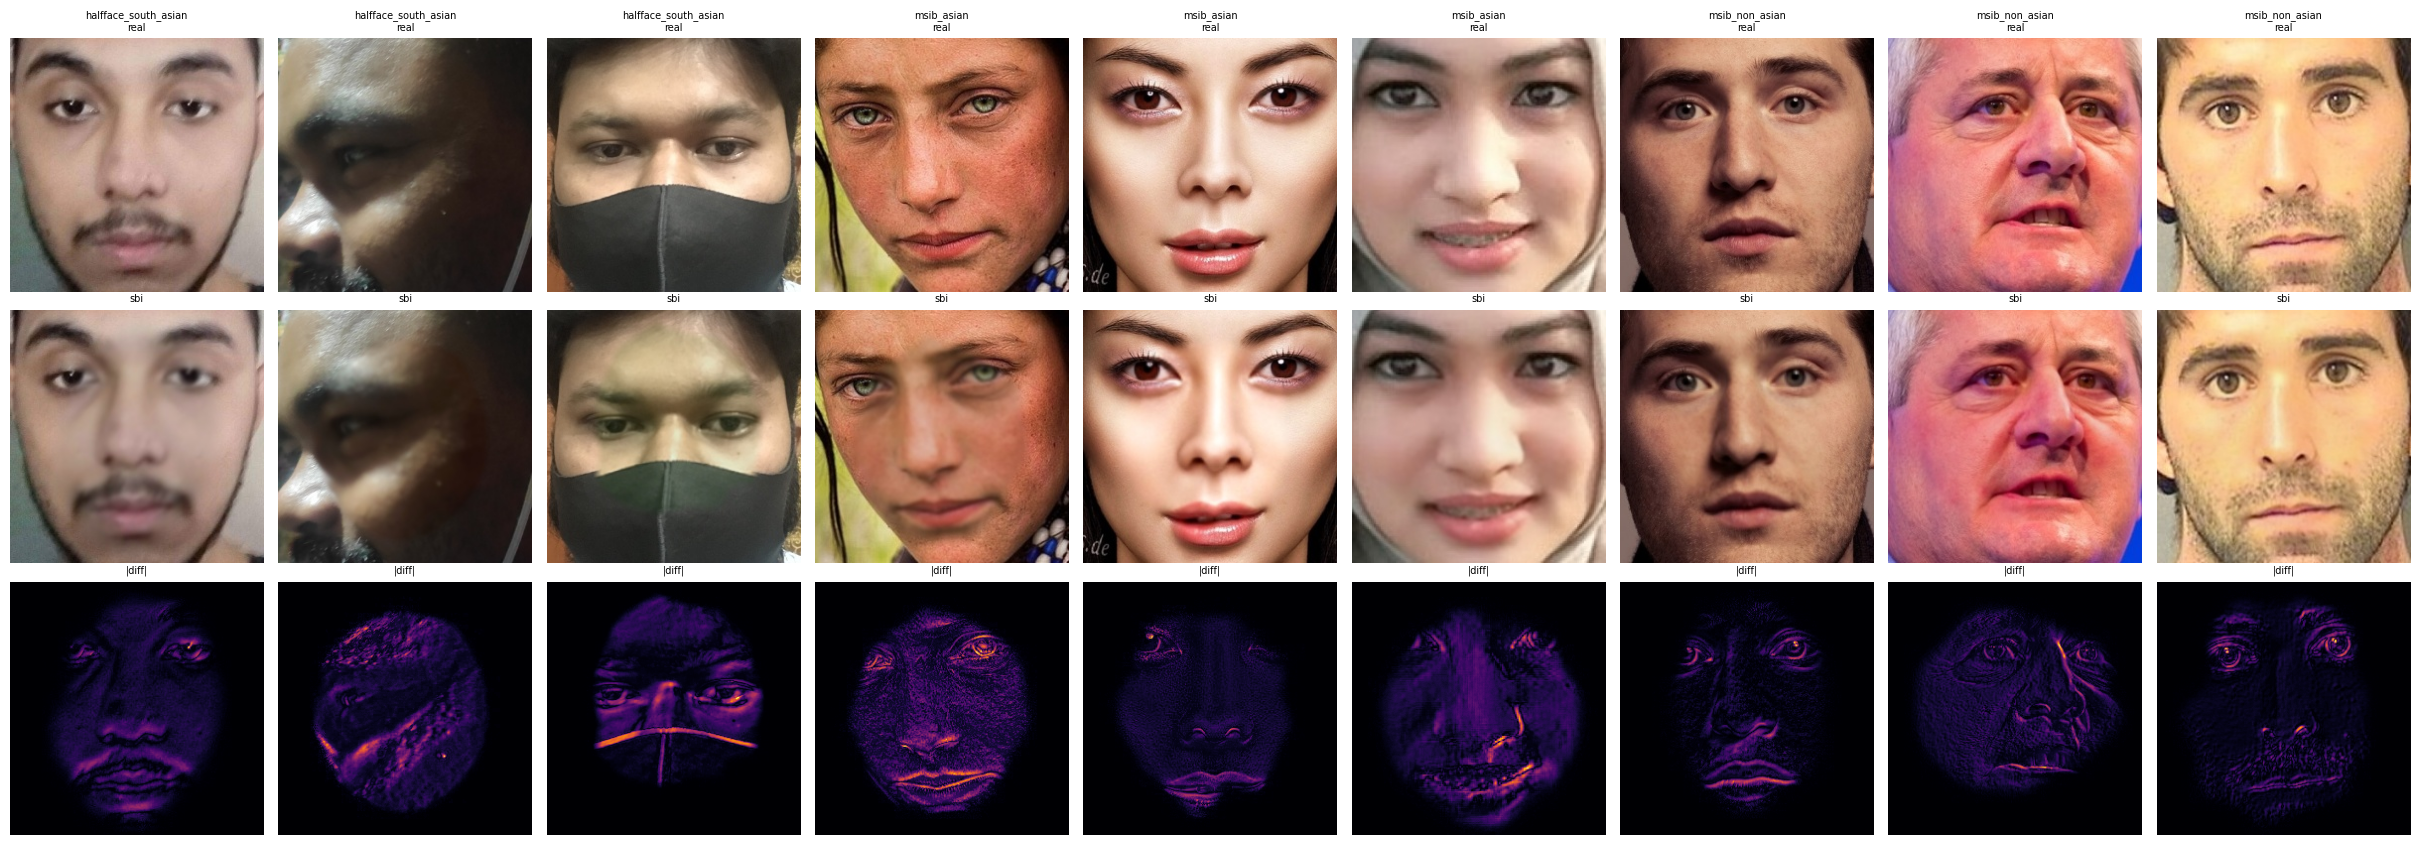

    filename                group identity split  det_score
p001_00m.jpg halfface_south_asian     p001 train   0.999928
p001_01m.jpg halfface_south_asian     p001 train   0.999668
p001_02m.jpg halfface_south_asian     p001 train   0.999693
p001_10m.jpg halfface_south_asian     p001 train   0.999852
p001_11m.jpg halfface_south_asian     p001 train   0.995829
p001_12m.jpg halfface_south_asian     p001 train   0.998729
p002_00m.jpg halfface_south_asian     p002   val   0.998241
p002_01m.jpg halfface_south_asian     p002   val   0.993108
p002_02m.jpg halfface_south_asian     p002   val   0.995352
p002_10m.jpg halfface_south_asian     p002   val   0.994216


In [11]:
import matplotlib.pyplot as plt

show = (man.groupby("group", group_keys=False)
           .apply(lambda g: g.sample(min(3, len(g)), random_state=2))
           .reset_index(drop=True))

n = len(show)
fig, axes = plt.subplots(3, n, figsize=(2.7 * n, 8.5), squeeze=False)
for j, r in enumerate(show.itertuples(index=False)):
    real = plt.imread(OUT / r.real_path)
    sbi = plt.imread(OUT / r.sbi_path)
    diff = np.abs(sbi.astype(int) - real.astype(int)).sum(2)
    for i, (im, t, kw) in enumerate([(real, "real", {}), (sbi, "sbi", {}),
                                     (diff, "|diff|", dict(cmap="inferno"))]):
        axes[i][j].imshow(im, **kw)
        axes[i][j].set_title(f"{r.group}\n{t}" if i == 0 else t, fontsize=7)
        axes[i][j].axis("off")
plt.tight_layout(); plt.show()

print(man[["filename", "group", "identity", "split", "det_score"]].head(10).to_string(index=False))